(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


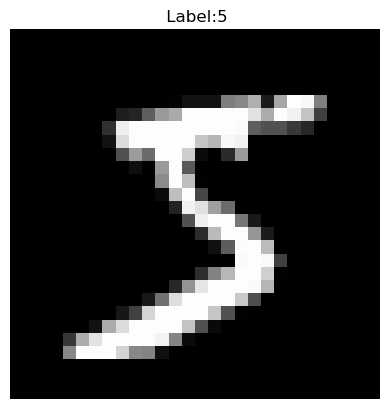

(60000, 28, 28, 1)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)                   │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_34 (MaxPooling2D)      │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_16 (Flatten)                 │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9492 - loss: 0.1690 - val_accuracy: 0.9850 - val_loss: 0.0517
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9849 - loss: 0.0492 - val_accuracy: 0.9883 - val_loss: 0.0376
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9888 - loss: 0.0347 - val_accuracy: 0.9890 - val_loss: 0.0395
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9926 - loss: 0.0240 - val_accuracy: 0.9905 - val_loss: 0.0320
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9941 - loss: 0.0183 - val_accuracy: 0.9913 - val_loss: 0.0325
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9899 - loss: 0.0305
Test Accuracy:0.9898999929428101


Enter any number 44


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
predicted :3
Actual:3


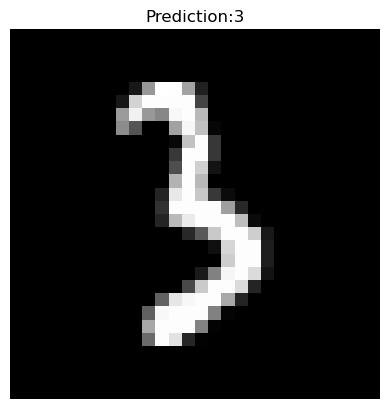

In [43]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)
plt.imshow(x_train[0], cmap="grey")
plt.title(f" Label:{y_train[0]}")
plt.axis("off")
plt.show()
x_train=x_train/255.0
x_test=x_test/255.0
x_train=x_train[...,None]
x_test=x_test[...,None]
print(x_train.shape)
model=keras.Sequential([
    keras.Input(shape=(28,28,1)),
    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(10,activation="softmax")
])
model.summary()
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.fit(x_train,y_train,epochs=5,batch_size=64,validation_split=0.1)
test_loss,test_accuracy,=model.evaluate(x_test,y_test)
print(f"Test Accuracy:{test_accuracy}")
N=int(input("Enter any number"))
prediction=model.predict(x_test[N:N+1])
predicted_digit=prediction.argmax()
print(f"predicted :{predicted_digit}")
print(f"Actual:{y_test[N]}")
plt.imshow(x_test[N].squeeze(),cmap="gray")
plt.title(f"Prediction:{predicted_digit}")
plt.axis("off")
plt.show()